# DBSCAN on the full EMNIST dataset — CPU benchmark
## Corrected fit-time and carbon methodology

This notebook clusters the **full EMNIST Digits dataset (train + test = 280,000 images)**.

### CPU-vs-GPU study interpretation

DBSCAN has a standard `fit` / `fit_predict` clustering stage, but standard DBSCAN
does **not** provide a normal separate prediction/inference stage for unseen
observations. Therefore this notebook reports:

- **DBSCAN fit/clustering time**
- clustering quality
- energy and CO₂e **per complete DBSCAN fit**

It does **not** report a fabricated inference time.

### Corrected measurement design

- preprocessing and automatic `eps`/`min_samples` selection are outside the benchmark;
- GPU host→device transfer is performed before timing and energy tracking;
- fit time is measured without CodeCarbon running;
- CodeCarbon uses `tracking_mode="process"`;
- CPU tracking explicitly excludes GPUs, GPU tracking uses GPU 0;
- `measure_power_secs=1`;
- carbon is measured in **3 long blocks**;
- each block performs complete DBSCAN fits until at least 30 seconds have elapsed;
- block emissions and energy are divided by the number of completed fits.

\[
CO_{2,\;per\;fit} =
\frac{CO_{2,\;block}}{N_{fits}}
\]

The CPU and GPU notebooks use the same full dataset, PCA representation,
`eps`, `min_samples`, and evaluation logic.


In [1]:
!pip install -q codecarbon
# Optional GPU DBSCAN (uncomment if DEVICE='cuda' and cuML missing; slow to install):
# !pip install -q --extra-index-url=https://pypi.nvidia.com "cuml-cu12==24.*"
try:
    import cuml, cupy
    print('cuML available:', cuml.__version__)
except Exception as e:
    print('cuML not available -> CPU backend will be used. (', e, ')')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 40.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore 4.3.0 requires cryptography<49,>=42, but you have cryptography 50.0.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 50.0.0 which is inc

## 1. Config — edit this cell

In [2]:
# ------------------------- CONFIG ------------------------- #
DEVICE           = "cpu"   # fixed for this notebook
SPLIT            = "digits"            # full digits train + test = 280,000 images
PCA_COMPONENTS   = 10
EPS              = None
MIN_SAMPLES      = None
KNEE_SAMPLE      = 50000
MAX_AVG_NEIGHBORS = 200
SAMPLE           = None                # None = FULL dataset
USE_CARBON       = True
DATA_ROOT        = "./data"

# Corrected CodeCarbon design
CARBON_MEASURE_SECS = 1
ENERGY_BLOCKS       = 3
ENERGY_MIN_DURATION_S = 30.0
ENERGY_COOLDOWN_S   = 5.0
# ---------------------------------------------------------- #


## 2. Backend selection (CPU sklearn / GPU cuML)

In [3]:
import time
import numpy as np


def select_backend(choice):
    choice = choice.lower()
    want_gpu = choice in ("cuda", "gpu", "auto")
    gpu_ok = False
    if want_gpu:
        try:
            import cuml, cupy  # noqa
            gpu_ok = True
        except Exception as e:
            if choice in ("cuda", "gpu"):
                raise RuntimeError(f"DEVICE='{choice}' but cuML/cupy not importable: {e}")
            print(f"cuML unavailable ({e}); falling back to CPU (scikit-learn).")
    if gpu_ok:
        from cuml.cluster import DBSCAN as cuDBSCAN
        from cuml.neighbors import NearestNeighbors as cuNN
        print("Backend: GPU (RAPIDS cuML)")
        return {"name": "gpu", "DBSCAN": cuDBSCAN, "NearestNeighbors": cuNN}
    from sklearn.cluster import DBSCAN as skDBSCAN
    from sklearn.neighbors import NearestNeighbors as skNN
    print("Backend: CPU (scikit-learn)")
    return {"name": "cpu", "DBSCAN": skDBSCAN, "NearestNeighbors": skNN}


backend = select_backend(DEVICE)

Backend: CPU (scikit-learn)


## 3. Load full EMNIST (train + test) and PCA-reduce

In [4]:
def load_emnist(split, data_root, sample):
    from torchvision import datasets
    print(f"Loading EMNIST split='{split}' (downloading if needed) ...")
    train = datasets.EMNIST(root=data_root, split=split, train=True, download=True)
    test  = datasets.EMNIST(root=data_root, split=split, train=False, download=True)

    def to_np(ds):
        X = ds.data.numpy().astype(np.float32).reshape(len(ds), -1) / 255.0
        y = ds.targets.numpy().astype(np.int64)
        return X, y

    Xtr, ytr = to_np(train); Xte, yte = to_np(test)
    X = np.concatenate([Xtr, Xte], axis=0)
    y = np.concatenate([ytr, yte], axis=0)
    if sample is not None and sample < X.shape[0]:
        rng = np.random.default_rng(0)
        idx = rng.choice(X.shape[0], size=sample, replace=False)
        X, y = X[idx], y[idx]
    print(f"Full dataset: X={X.shape} (train={len(train)} + test={len(test)}), "
          f"{len(np.unique(y))} true classes")
    return X, y


def reduce_pca(X, n_components):
    if n_components is None:
        print("PCA disabled: using raw 784-dim pixels.")
        return X.astype(np.float32)
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    print(f"PCA: 784 -> {n_components} dims (standardized) ...")
    Xs = StandardScaler().fit_transform(X)
    Xp = PCA(n_components=n_components, random_state=0).fit_transform(Xs)
    return np.ascontiguousarray(Xp.astype(np.float32))


X, y = load_emnist(SPLIT, DATA_ROOT, SAMPLE)
X = reduce_pca(X, PCA_COMPONENTS)
dim = X.shape[1]
print("Working matrix:", X.shape)

Loading EMNIST split='digits' (downloading if needed) ...


100%|██████████| 562M/562M [00:03<00:00, 158MB/s]


Full dataset: X=(280000, 784) (train=240000 + test=40000), 10 true classes
PCA: 784 -> 10 dims (standardized) ...
Working matrix: (280000, 10)


## 4. Robust `eps` / `min_samples` selection with a memory guardrail

**The bug this fixes:** in reduced-but-still-high-D space the sorted k-distance curve is a nearly flat band with a sharp spike in the last ~1% (outliers). A plain chord/knee detector locks onto that spike and returns an `eps` close to the *typical* inter-point distance — so almost every pair becomes a neighbor, the neighbor graph needs tens of GB, and the kernel dies.

**Fixes applied:**
1. **Trim the outlier tail** (drop the top ~2%) and lightly smooth before knee-finding; prefer the `kneed` library if present, else a robust chord method on the trimmed curve.
2. **Memory guard (the important one):** on a small sample, count how many points fall within the candidate `eps`, **rescaled to the full dataset** (neighbor count grows with #points). If the full-set average exceeds `MAX_AVG_NEIGHBORS`, shrink `eps` until it's safe. This *caps the neighbor-graph size* regardless of what the knee says, so OOM cannot happen.

In [5]:
def _to_numpy(a):
    """cupy (GPU) or numpy -> numpy."""
    return np.asarray(a.get() if hasattr(a, "get") else a)


def choose_min_samples(dim, user_value):
    if user_value is not None:
        return int(user_value)
    ms = int(max(2 * dim, 4))
    print(f"Auto min_samples = 2*dim = {ms}")
    return ms


def _subsample(X, m, seed=1):
    n = X.shape[0]
    if m and m < n:
        idx = np.random.default_rng(seed).choice(n, size=m, replace=False)
        return X[idx]
    return X


def kdist_sorted(Xk, k, backend):
    """Sorted distance to the k-th nearest neighbor for the sample Xk."""
    nn = backend["NearestNeighbors"](n_neighbors=k)
    nn.fit(Xk)
    dist, _ = nn.kneighbors(Xk)
    kth = _to_numpy(dist)[:, -1]
    return np.sort(kth.astype(np.float64))


def robust_knee(curve, trim_frac=0.02):
    """Knee of a sorted ascending curve, ignoring the extreme outlier tail."""
    m = len(curve)
    hi = max(10, int(m * (1.0 - trim_frac)))
    c = curve[:hi]
    if len(c) >= 11:
        c = np.convolve(c, np.ones(11) / 11.0, mode="same")
    # Prefer the kneed library if available.
    try:
        from kneed import KneeLocator
        x = np.arange(len(c))
        kl = KneeLocator(x, c, curve="convex", direction="increasing")
        if kl.knee is not None:
            i = int(kl.knee)
            return i, float(curve[min(i, m - 1)])
    except Exception:
        pass
    # Fallback: max perpendicular distance to the chord of the trimmed curve.
    x = np.arange(len(c), dtype=np.float64)
    x0, y0, x1, y1 = x[0], c[0], x[-1], c[-1]
    denom = np.hypot(x1 - x0, y1 - y0) + 1e-12
    perp = np.abs((y1 - y0) * x - (x1 - x0) * c + x1 * y0 - y1 * x0) / denom
    i = int(np.argmax(perp))
    return i, float(curve[min(i, m - 1)])


def avg_neighbors_within(Xk, eps, backend, cap_query=5000, k_query=512):
    """Average #points within `eps` on the sample Xk (backend-agnostic).

    Counts, among each query point's k nearest neighbors, how many are <= eps.
    The count saturates at k_query — which is fine, because saturation only
    happens when the neighborhood is far larger than the cap, i.e. exactly when
    we want the guard to shrink eps. Uses `kneighbors` (sklearn AND cuML have it);
    cuML's NearestNeighbors has no `radius`/`radius_neighbors` API.
    """
    n_fit = Xk.shape[0]
    k = int(min(k_query, n_fit))
    Xq = _subsample(Xk, min(cap_query, n_fit), seed=7)
    nn = backend["NearestNeighbors"](n_neighbors=k)
    nn.fit(Xk)
    dist, _ = nn.kneighbors(Xq)
    dist = _to_numpy(dist)
    counts = (dist <= eps).sum(axis=1)  # includes the point itself; matches DBSCAN convention
    return float(counts.mean())


def guarded_eps(Xk, eps0, backend, max_avg, scale=1.0):
    """Shrink eps until the FULL-set avg neighborhood <= max_avg.

    `scale` = N_full / N_sample rescales the subsample measurement up to the
    full dataset, since a point's neighbor count grows with the #points present.
    """
    eps = float(eps0)
    avg_full = float("inf")
    for _ in range(20):
        avg_sample = avg_neighbors_within(Xk, eps, backend)
        avg_full = avg_sample * scale
        print(f"  eps={eps:.4f} -> avg neighbors: sample ≈ {avg_sample:.1f}, full ≈ {avg_full:.1f}")
        if avg_full <= max_avg:
            return eps, avg_full
        eps *= 0.8
    return eps, avg_full


min_samples = choose_min_samples(dim, MIN_SAMPLES)
Xk = _subsample(X, KNEE_SAMPLE)
scale = X.shape[0] / Xk.shape[0]   # rescale subsample density -> full dataset
print(f"eps estimation on {Xk.shape[0]:,} points (of {X.shape[0]:,}); density scale x{scale:.2f}.")

if EPS is None:
    curve = kdist_sorted(Xk, min_samples, backend)
    knee_i, eps_knee = robust_knee(curve)
    print(f"Knee eps candidate = {eps_knee:.4f} (knee at {knee_i}/{len(curve)})")
    eps, avg_nb = guarded_eps(Xk, eps_knee, backend, MAX_AVG_NEIGHBORS, scale)
    print(f"Final eps = {eps:.4f}  (full-set avg neighbors ≈ {avg_nb:.1f} ≤ {MAX_AVG_NEIGHBORS})")
else:
    curve, knee_i = None, None
    eps = float(EPS)
    avg_nb = avg_neighbors_within(Xk, eps, backend) * scale
    print(f"User eps = {eps:.4f} (full-set avg neighbors ≈ {avg_nb:.1f})")

Auto min_samples = 2*dim = 20
eps estimation on 50,000 points (of 280,000); density scale x5.60.
Knee eps candidate = 11.0957 (knee at 48994/50000)
  eps=11.0957 -> avg neighbors: sample ≈ 426.8, full ≈ 2390.0
  eps=8.8765 -> avg neighbors: sample ≈ 305.7, full ≈ 1711.9
  eps=7.1012 -> avg neighbors: sample ≈ 166.7, full ≈ 933.7
  eps=5.6810 -> avg neighbors: sample ≈ 79.7, full ≈ 446.6
  eps=4.5448 -> avg neighbors: sample ≈ 46.5, full ≈ 260.1
  eps=3.6358 -> avg neighbors: sample ≈ 28.3, full ≈ 158.7
Final eps = 3.6358  (full-set avg neighbors ≈ 158.7 ≤ 200)


### k-distance graph (sanity check)

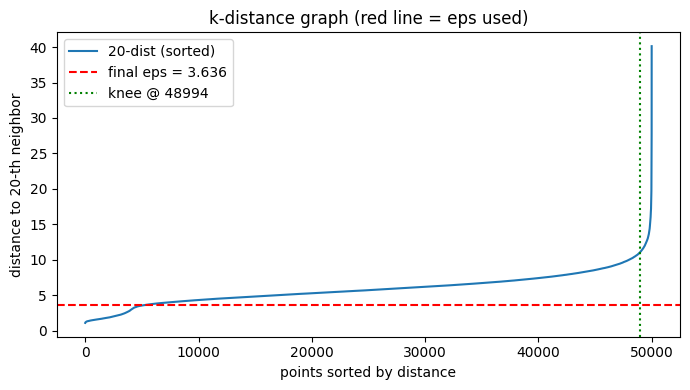

In [6]:
import matplotlib.pyplot as plt

if curve is not None:
    plt.figure(figsize=(7, 4))
    plt.plot(curve, lw=1.5, label=f"{min_samples}-dist (sorted)")
    plt.axhline(eps, color="r", ls="--", label=f"final eps = {eps:.3f}")
    if knee_i is not None:
        plt.axvline(knee_i, color="g", ls=":", label=f"knee @ {knee_i}")
    plt.xlabel("points sorted by distance")
    plt.ylabel(f"distance to {min_samples}-th neighbor")
    plt.title("k-distance graph (red line = eps used)")
    plt.legend(); plt.tight_layout(); plt.show()
else:
    print("eps set manually; skipping plot.")

## 5. Run DBSCAN — clean fit timing + long-block carbon measurement

The normal timing run measures only `fit_predict()`.

CodeCarbon is measured separately so monitoring overhead does not contaminate
the reported fit time. For GPU, the NumPy matrix is transferred to GPU once
before either measurement.


In [7]:
import gc
import pandas as pd

def _sync_gpu():
    if backend["name"] == "gpu":
        import cupy as cp
        cp.cuda.Stream.null.synchronize()

def _make_dbscan():
    if backend["name"] == "gpu":
        return backend["DBSCAN"](
            eps=eps,
            min_samples=min_samples,
        )
    return backend["DBSCAN"](
        eps=eps,
        min_samples=min_samples,
        algorithm="ball_tree",
        n_jobs=-1,
    )

# ------------------------------------------------------------
# Prepare execution data BEFORE timing / carbon measurement.
# This excludes host->GPU transfer from the GPU fit benchmark.
# ------------------------------------------------------------
if backend["name"] == "gpu":
    import cupy as cp
    X_run = cp.asarray(X)
    _sync_gpu()
else:
    X_run = X

print(
    f"Running clean DBSCAN fit on {X.shape[0]:,} x {dim} "
    f"using {backend['name'].upper()} ..."
)

# ------------------------------------------------------------
# A. CLEAN FIT TIME — CodeCarbon is OFF
# ------------------------------------------------------------
gc.collect()
_sync_gpu()

model = _make_dbscan()

t0 = time.perf_counter()
labels_device = model.fit_predict(X_run)
_sync_gpu()
fit_time = time.perf_counter() - t0

labels = _to_numpy(labels_device).astype(np.int32, copy=False)

print(f"Clean DBSCAN fit time: {fit_time:.3f} s")

# ------------------------------------------------------------
# B. LONG-BLOCK CODECARBON — FIT WORKLOAD ONLY
# ------------------------------------------------------------
energy_rows = []

def _new_tracker(block):
    if not USE_CARBON:
        return None

    try:
        from codecarbon import EmissionsTracker

        kwargs = dict(
            project_name=f"dbscan_emnist_{backend['name']}_block_{block}",
            measure_power_secs=CARBON_MEASURE_SECS,
            tracking_mode="process",
            gpu_ids=([0] if backend["name"] == "gpu" else []),
            save_to_file=False,
            save_to_api=False,
            log_level="error",
        )

        return EmissionsTracker(**kwargs)

    except Exception as e:
        print(f"CodeCarbon unavailable ({e}); continuing without carbon tracking.")
        return None

if USE_CARBON:
    for block in range(1, ENERGY_BLOCKS + 1):
        gc.collect()
        _sync_gpu()

        tracker = _new_tracker(block)
        if tracker is None:
            break

        tracker.start()
        _sync_gpu()

        block_start = time.perf_counter()
        fit_count = 0

        try:
            while True:
                energy_model = _make_dbscan()
                pred = energy_model.fit_predict(X_run)
                _sync_gpu()

                fit_count += 1

                del energy_model
                del pred

                if (time.perf_counter() - block_start) >= ENERGY_MIN_DURATION_S:
                    break

        finally:
            _sync_gpu()
            duration_s = time.perf_counter() - block_start
            emissions_kg = tracker.stop()

        data = getattr(tracker, "final_emissions_data", None)

        def attr(name):
            if data is None:
                return np.nan
            value = getattr(data, name, np.nan)
            return np.nan if value is None else value

        total_energy_kwh = attr("energy_consumed")
        cpu_energy_kwh = attr("cpu_energy")
        gpu_energy_kwh = attr("gpu_energy")
        ram_energy_kwh = attr("ram_energy")

        row = {
            "block": block,
            "device": backend["name"],
            "fit_count": fit_count,
            "duration_s": duration_s,
            "mean_fit_time_in_block_s": duration_s / fit_count,
            "emissions_block_kg": emissions_kg,
            "emissions_per_fit_kg": emissions_kg / fit_count,
            "emissions_per_fit_g": emissions_kg * 1000.0 / fit_count,
            "energy_block_kwh": total_energy_kwh,
            "energy_per_fit_kwh": total_energy_kwh / fit_count,
            "energy_per_fit_wh": total_energy_kwh * 1000.0 / fit_count,
            "cpu_energy_per_fit_kwh": cpu_energy_kwh / fit_count,
            "gpu_energy_per_fit_kwh": gpu_energy_kwh / fit_count,
            "ram_energy_per_fit_kwh": ram_energy_kwh / fit_count,
            "carbon_country": getattr(data, "country_name", None) if data is not None else None,
        }

        energy_rows.append(row)

        print(
            f"Energy block {block}: {fit_count} fit(s), "
            f"{duration_s:.1f}s, "
            f"{row['emissions_per_fit_g']:.6f} g CO2e/fit, "
            f"{row['energy_per_fit_wh']:.6f} Wh/fit"
        )

        if block < ENERGY_BLOCKS and ENERGY_COOLDOWN_S > 0:
            time.sleep(ENERGY_COOLDOWN_S)

energy_df = pd.DataFrame(energy_rows)
if not energy_df.empty:
    display(energy_df.round(8))


Running clean DBSCAN fit on 280,000 x 10 using CPU ...


[codecarbon WARNING @ 15:06:33] Multiple instances of codecarbon are allowed to run at the same time.


Clean DBSCAN fit time: 206.875 s
Energy block 1: 1 fit(s), 202.2s, 0.928158 g CO2e/fit, 1.444878 Wh/fit
Energy block 2: 1 fit(s), 202.9s, 0.932908 g CO2e/fit, 1.452272 Wh/fit
Energy block 3: 1 fit(s), 200.9s, 0.922757 g CO2e/fit, 1.436470 Wh/fit


,block,device,fit_count,duration_s,mean_fit_time_in_block_s,emissions_block_kg,emissions_per_fit_kg,emissions_per_fit_g,energy_block_kwh,energy_per_fit_kwh,energy_per_fit_wh,cpu_energy_per_fit_kwh,gpu_energy_per_fit_kwh,ram_energy_per_fit_kwh,carbon_country
0,1,cpu,1,202.155484,202.155484,0.000928,0.000928,0.928158,0.001445,0.001445,1.444878,0.000884,0.0,0.000561,Taiwan
1,2,cpu,1,202.949451,202.949451,0.000933,0.000933,0.932908,0.001452,0.001452,1.452272,0.000889,0.0,0.000563,Taiwan
2,3,cpu,1,200.853015,200.853015,0.000923,0.000923,0.922757,0.001436,0.001436,1.436470,0.000881,0.0,0.000556,Taiwan


## 6. Evaluate & report

In [8]:
labels = np.asarray(labels)
n = len(labels)
noise = int((labels == -1).sum())
n_clusters = len(set(labels.tolist()) - {-1})
mask = labels != -1

metrics = {}

try:
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

    if mask.sum() > 0:
        metrics["NMI (excl. noise)"] = normalized_mutual_info_score(
            y[mask], labels[mask]
        )
        metrics["ARI (excl. noise)"] = adjusted_rand_score(
            y[mask], labels[mask]
        )

    metrics["NMI (noise=label)"] = normalized_mutual_info_score(
        y, labels
    )
    metrics["ARI (noise=label)"] = adjusted_rand_score(
        y, labels
    )

except Exception as e:
    print(f"(sklearn metrics skipped: {e})")

try:
    from scipy.optimize import linear_sum_assignment

    if n_clusters >= 1 and mask.sum() > 0:
        lab = labels[mask]
        yt = y[mask]

        uniq = np.unique(lab)
        remap = {c: i for i, c in enumerate(uniq)}
        lab2 = np.array([remap[c] for c in lab])

        cost = np.zeros(
            (len(uniq), int(y.max()) + 1),
            dtype=np.int64,
        )

        for c, t in zip(lab2, yt):
            cost[c, t] += 1

        r, cc = linear_sum_assignment(-cost)

        metrics["Accuracy (clustered pts)"] = (
            cost[r, cc].sum() / mask.sum()
        )

except Exception as e:
    print(f"(accuracy skipped: {e})")

print("=" * 68)
print("RESULTS — DBSCAN")
print("=" * 68)
print(f"Samples clustered       : {X.shape[0]:,}")
print(f"Feature dim (post-PCA)  : {dim}")
print(f"Backend                 : {backend['name']}")
print(f"eps                     : {eps:.4f}")
print(f"min_samples             : {min_samples}")
print(f"Clusters found          : {n_clusters}")
print(f"Noise points            : {noise:,} ({100.0 * noise / n:.2f}%)")
print(f"DBSCAN fit time         : {fit_time:.3f} s")
print("Separate inference time : N/A — standard DBSCAN has no predict stage")

for key, value in metrics.items():
    print(f"{key:<24}: {value:.4f}")

if not energy_df.empty:
    carbon_mean = energy_df["emissions_per_fit_g"].mean()
    carbon_sd = energy_df["emissions_per_fit_g"].std()
    energy_mean = energy_df["energy_per_fit_wh"].mean()
    energy_sd = energy_df["energy_per_fit_wh"].std()

    print(
        f"CO2e per fit            : {carbon_mean:.6f} ± "
        f"{carbon_sd:.6f} g"
    )
    print(
        f"Energy per fit          : {energy_mean:.6f} ± "
        f"{energy_sd:.6f} Wh"
    )
    print(
        f"CodeCarbon blocks       : {len(energy_df)} "
        f"(min {ENERGY_MIN_DURATION_S:.0f}s each)"
    )

print("=" * 68)

# Compact CSV-ready result
result_summary = pd.DataFrame([{
    "algorithm": "DBSCAN",
    "device": backend["name"],
    "samples": X.shape[0],
    "features": dim,
    "eps": eps,
    "min_samples": min_samples,
    "fit_time_s": fit_time,
    "inference_time_s": np.nan,
    "clusters": n_clusters,
    "noise_fraction": noise / n,
    "co2_per_fit_mean_g": (
        energy_df["emissions_per_fit_g"].mean()
        if not energy_df.empty else np.nan
    ),
    "co2_per_fit_std_g": (
        energy_df["emissions_per_fit_g"].std()
        if not energy_df.empty else np.nan
    ),
    "energy_per_fit_mean_wh": (
        energy_df["energy_per_fit_wh"].mean()
        if not energy_df.empty else np.nan
    ),
    "energy_per_fit_std_wh": (
        energy_df["energy_per_fit_wh"].std()
        if not energy_df.empty else np.nan
    ),
    **metrics,
}])

display(result_summary.round(8))


RESULTS — DBSCAN
Samples clustered       : 280,000
Feature dim (post-PCA)  : 10
Backend                 : cpu
eps                     : 3.6358
min_samples             : 20
Clusters found          : 18
Noise points            : 162,928 (58.19%)
DBSCAN fit time         : 206.875 s
Separate inference time : N/A — standard DBSCAN has no predict stage
NMI (excl. noise)       : 0.1482
ARI (excl. noise)       : 0.0298
NMI (noise=label)       : 0.1623
ARI (noise=label)       : 0.0639
Accuracy (clustered pts): 0.2785
CO2e per fit            : 0.927941 ± 0.005079 g
Energy per fit          : 1.444540 ± 0.007907 Wh
CodeCarbon blocks       : 3 (min 30s each)


,algorithm,device,samples,features,eps,min_samples,fit_time_s,inference_time_s,clusters,noise_fraction,co2_per_fit_mean_g,co2_per_fit_std_g,energy_per_fit_mean_wh,energy_per_fit_std_wh,NMI (excl. noise),ARI (excl. noise),NMI (noise=label),ARI (noise=label),Accuracy (clustered pts)
0,DBSCAN,cpu,280000,10,3.635831,20,206.874602,NaN,18,0.581886,0.927941,0.005079,1.44454,0.007907,0.148217,0.029833,0.162311,0.063936,0.278521


## 7. Top clusters: sizes & mean images

Top clusters (id: size):
     0: 111,533
     1: 5,114
     2: 94
     5: 43
     8: 37
    12: 33
     7: 22
     9: 22
    11: 20
    10: 20


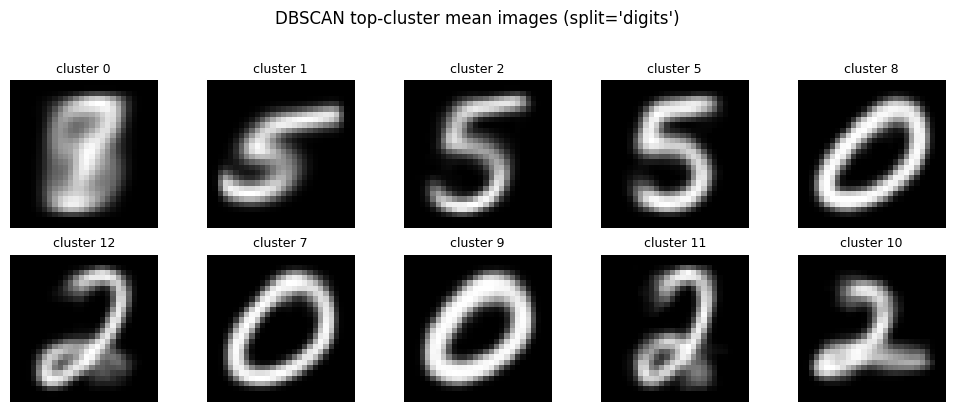

In [9]:
if n_clusters == 0:
    print("No clusters found (all noise). Try a larger eps, fewer PCA dims, or smaller min_samples.")
else:
    uniq, counts = np.unique(labels[labels != -1], return_counts=True)
    order = np.argsort(-counts)
    top = uniq[order][:10]; top_counts = counts[order][:10]
    print("Top clusters (id: size):")
    for c, s in zip(top, top_counts):
        print(f"  {int(c):>4}: {int(s):,}")

    from torchvision import datasets as _ds
    _tr = _ds.EMNIST(root=DATA_ROOT, split=SPLIT, train=True, download=False)
    _te = _ds.EMNIST(root=DATA_ROOT, split=SPLIT, train=False, download=False)
    raw = np.concatenate([_tr.data.numpy(), _te.data.numpy()], axis=0).astype(np.float32) / 255.0
    if SAMPLE is not None and SAMPLE < raw.shape[0]:
        idx = np.random.default_rng(0).choice(raw.shape[0], size=SAMPLE, replace=False)
        raw = raw[idx]

    ncols = min(len(top), 5); nrows = (len(top) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, top):
        ax.imshow(raw[labels == c].mean(axis=0).T, cmap="gray")  # .T = EMNIST orientation
        ax.set_title(f"cluster {int(c)}", fontsize=9); ax.axis("off")
    for ax in axes[len(top):]:
        ax.axis("off")
    plt.suptitle(f"DBSCAN top-cluster mean images (split='{SPLIT}')", y=1.02)
    plt.tight_layout(); plt.show()